# Applied Machine Learning

# Assignment 1

# Classifying emails as SPAM and NON - SPAM

# Parag Soni - R00208553

# Introduction

Classification consists of trying to predict which class a particular sample from a population comes from. Text classification is one of it and the most important tasks in Natural Language Processing. It is the process of classifying text strings or documents into different categories, depending upon the contents of the strings. Text classification has a variety of applications, such as detecting user sentiment from a tweet, classifying an email as spam or ham, classifying blog posts into different categories, automatic tagging of customer queries, and so on.

This report demonstrates how do we create a supervised classification pipeline to classify emails as spam or non-spam from the training data of the dataset.The dataset is a collection of public domain emails from the Enron corporation. The emails have been manually classified as spam and non-spam.

The dataset contains 5975 emails in total with 3672 emails classified as hap or legitimate and 1500 emails classified as spam.

Pipeline is divide in to numerous stages :

1. Data Pre-Processing

2. Exploratory Data Analysis

3. Supervised classification

4. Model selection

5. Model Evaluation

#### Importing required libraries 

In [12]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import MinMaxScaler

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from wordcloud import WordCloud
import re

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize 
import sys
import os
print(os.listdir("D:\Sem 2\App ML\Assignment 1\enron1"))

['ham', 'spam', 'Summary.txt']


Reading the dataset from the system path, since the data is distributes in multiple files, one text file per email in two different directories/folders as ham and spam and not composed in a single file. 

It can be done by varios approaches like with 

1. OS Module (os.listdir("test/"))

2. Using Glob Module

I have used OS module to get all the files and iterate through them in order to store them in a list and then to a data frame using pandas DataFrame function. Following above method we have two different data frames one for Ham/legitimate emails and one for Spam emails.

In [165]:
# reading files
ham_dir = "D:/Sem 2/App ML/Assignment 1/enron1/ham/"
ham_files = os.listdir(ham_dir)#method in python is used to get the list of all files and directories in the specified directory.
#print(ham_files)
list_ham_files = []
for file_path in ham_files:
    with open(ham_dir+file_path,encoding="utf8", errors='ignore') as f:
        list_ham_files.append(f.read())

ham_df = pd.DataFrame(list_ham_files, columns=["email"])
ham_df["label"] = 0

spam_dir = "D:/Sem 2/App ML/Assignment 1/enron1/spam/"
spam_files = os.listdir(spam_dir)
list_spam_files = []
for file_path in spam_files:
    with open(spam_dir+file_path, encoding="utf8", errors='ignore') as f:
        list_spam_files.append(f.read())

spam_df = pd.DataFrame(list_spam_files, columns=["email"])
spam_df["label"] = 1

In [166]:
spam_df

,email,label
0,Subject: dobmeos with hgh my energy level has ...,1
1,Subject: your prescription is ready . . oxwq s...,1
2,Subject: get that new car 8434\npeople nowthe ...,1
3,"Subject: await your response\ndear partner ,\n...",1
4,"Subject: coca cola , mbna america , nascar par...",1
...,...,...
1495,Subject: our pro - forma invoice attached\ndiv...,1
1496,Subject: str _ rndlen ( 2 - 4 ) } { extra _ ti...,1
1497,Subject: check me out !\n61 bb\nhey derm\nbbbb...,1
1498,Subject: hot jobs\nglobal marketing specialtie...,1


In [167]:
ham_df

,email,label
0,Subject: christmas tree farm pictures\n,0
1,"Subject: vastar resources , inc .\ngary , prod...",0
2,Subject: calpine daily gas nomination\n- calpi...,0
3,Subject: re : issue\nfyi - see note below - al...,0
4,Subject: meter 7268 nov allocation\nfyi .\n- -...,0
...,...,...
3667,Subject: re : tenaska iv\ni ' ll call you on t...,0
3668,"Subject: generic contract\nhi daren ,\nsorry f...",0
3669,Subject: re : contracts and credit\nthanks - -...,0
3670,"Subject: re : tenaska iv\nok , since we don ' ...",0


Merging data frames ham_df and spam_df in one main dataframe as 'data'

In [168]:
frames = [ham_df, spam_df]

data = pd.concat(frames)
data

,email,label
0,Subject: christmas tree farm pictures\n,0
1,"Subject: vastar resources , inc .\ngary , prod...",0
2,Subject: calpine daily gas nomination\n- calpi...,0
3,Subject: re : issue\nfyi - see note below - al...,0
4,Subject: meter 7268 nov allocation\nfyi .\n- -...,0
...,...,...
1495,Subject: our pro - forma invoice attached\ndiv...,1
1496,Subject: str _ rndlen ( 2 - 4 ) } { extra _ ti...,1
1497,Subject: check me out !\n61 bb\nhey derm\nbbbb...,1
1498,Subject: hot jobs\nglobal marketing specialtie...,1


Adding a length feature to the dataframe as the length of email messages.

In [169]:
data['length'] = data['email'].apply(len)
data

,email,label,length
0,Subject: christmas tree farm pictures\n,0,38
1,"Subject: vastar resources , inc .\ngary , prod...",0,4316
2,Subject: calpine daily gas nomination\n- calpi...,0,76
3,Subject: re : issue\nfyi - see note below - al...,0,1191
4,Subject: meter 7268 nov allocation\nfyi .\n- -...,0,1159
...,...,...,...
1495,Subject: our pro - forma invoice attached\ndiv...,1,576
1496,Subject: str _ rndlen ( 2 - 4 ) } { extra _ ti...,1,76
1497,Subject: check me out !\n61 bb\nhey derm\nbbbb...,1,93
1498,Subject: hot jobs\nglobal marketing specialtie...,1,148


Making a copy for further use

In [70]:
data_ham  = data[data['label'] == 0].copy()
data_spam = data[data['label'] == 1].copy()

# 1. Data pre-processing

Once the dataset has been imported, the next step is to preprocess the text. Text may contain numbers, special characters, and unwanted spaces. Depending upon the problem we face, we may or may not need to remove these special characters and numbers from text. Data pre-processing is a key aspect of machine learning and is a must thing to do. Its a process of preparing the raw data and making it suitable for a machine learning model. It is the first and crucial step while creating a machine learning model. As per our data is concerned it needs data to be preprocessed.

This preprocess is diveded into two sections below:

1. Splitting dataframe into two sets 'training_data' and 'Tetesting_data' in order to train model and predict it accuracy.

2. Feature extraction

#### 1.1 Splitting dataframe into 2 data frames Training (70%) and Test (30%)

In [170]:
#dropping duplicate data
data.drop_duplicates(inplace = True)

In [171]:
data

,email,label,length
0,Subject: christmas tree farm pictures\n,0,38
1,"Subject: vastar resources , inc .\ngary , prod...",0,4316
2,Subject: calpine daily gas nomination\n- calpi...,0,76
3,Subject: re : issue\nfyi - see note below - al...,0,1191
4,Subject: meter 7268 nov allocation\nfyi .\n- -...,0,1159
...,...,...,...
1495,Subject: our pro - forma invoice attached\ndiv...,1,576
1496,Subject: str _ rndlen ( 2 - 4 ) } { extra _ ti...,1,76
1497,Subject: check me out !\n61 bb\nhey derm\nbbbb...,1,93
1498,Subject: hot jobs\nglobal marketing specialtie...,1,148


In [179]:
# split the data into train and test set
from sklearn.model_selection import train_test_split

training_data, testing_data = train_test_split(data, test_size=0.3, random_state=553)

In [180]:
training_data

,email,label,length
280,"Subject: reply soon ! ! !\ndear sir ,\ni know ...",1,4723
727,Subject: get a $ 25 certificate just for respo...,0,1739
2704,Subject: re : noms / actual flow for 03 / 09 t...,0,525
1673,Subject: enron / hpl noms . for 9 / 26 / 00\na...,0,159
3365,Subject: enw meeting / teambuilding event - ji...,0,638
...,...,...,...
1571,Subject: juvenile diabetes foundation fundrais...,0,2117
3064,Subject: shut - in of meter 989842\nmeter 0989...,0,274
3335,Subject: inter / intra gisb for enron north am...,0,897
624,Subject: viagra _ cialis _ levitra _ ambien _ ...,1,1228


In [182]:
training_data.groupby("label").describe()

length                                                               
        count         mean          std   min    25%    50%     75%      max
label                                                                       
0      2474.0   983.336297  1426.635583  17.0  229.0  524.0  1238.0  31860.0
1      1021.0  1201.720862  1700.121846  10.0  300.0  579.0  1309.0  14460.0

Training data has 2474 rows labeled "0" i.e., Ham emails and 1021 rows labeled as "1" i.e., Spam emails.

In [183]:
testing_data.groupby("label").describe()

length                                                               
        count         mean          std   min    25%    50%     75%      max
label                                                                       
0      1057.0   962.469253  1265.225284  39.0  249.0  554.0  1209.0  16061.0
1       442.0  1292.115385  2054.242074  18.0  296.0  577.5  1223.5  21749.0

Testing data has 1057 rows labeled "0" i.e., Ham emails and 442 rows labeled as "1" i.e., Spam emails.

In [189]:
#saving train and test data in file
training_data.to_csv (r'D:/Sem 2/App ML/Assignment 1/enron1/train.csv', index = False, header=True)
testing_data.to_csv (r'D:/Sem 2/App ML/Assignment 1/enron1/test.csv', index = False, header=True)

#### 1.2 Feature Extraction 

Feature extraction refers to the process of transforming raw data into numerical features that can be processed while preserving the information in the original data set. It yields better results than applying machine learning directly to the raw data. It also helps to build the model with less machine effort and also increases the speed of learning. Lets explore it more below.

As per sklearn documentation https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction "raw data, a sequence of symbols cannot be fed directly to the algorithms themselves as most of them expect numerical feature vectors with a fixed size rather than the raw text documents with variable length". 

In order to perform this scikit-learn provides utilities to extract numerical features from text content.

1. Tokenization : assingning an integer id to every toke or feature
2. counting the occurrences of tokens in each document.
3. normalizing and weighting with diminishing importance tokens that occur in the majority of samples / documents.
4. vectorization the general process of turning a collection of text documents into numerical feature vectors.

Combination of above in commomn terms is known as "Bag Of Words", its a Natural Language Processing technique of text modelling it consists of all the relevant features/words with the count of their occurences in all the documnets but it does not store the location of where this word occurs. Below is the more detailed defition of it.

#### Stopwords

From sklearn documentation: https://scikit-learn.org/stable/modules/feature_extraction.html#stop-words
Stop words are words like “and”, “the”, “him”, which are presumed to be uninformative in representing the content of a text,
and which may be removed to avoid them being construed as signal for prediction.
Sometimes, however, similar words are useful for prediction, such as in classifying writing style or personality.

There are several known issues in the ’english’ stop word list of sklearn and its making a choiceof choosing any stop word list is very crucial hence I have used stopwords from NLTK.

#### NLTK

In [190]:
from nltk.corpus import stopwords
#stopwords.words("english")

In [191]:
# Imports for punctuations from string library
import re
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

#### Function to convert string to lower case and remove stopwords and punctuations.

In [192]:
def remove_punctuation_and_stopwords(email):
    
    email_with_no_punctuation = [mail_words for mail_words in email if mail_words not in string.punctuation]
    email_with_no_punctuation = "".join(email_with_no_punctuation).split()
    
    email_with_no_punctuation_no_stopwords = \
        [word.lower() for word in email_with_no_punctuation if word.lower() not in stopwords.words("english")]
        
    return email_with_no_punctuation_no_stopwords

Cleaning training data

In [194]:
clean_training_data = training_data['email'].apply(remove_punctuation_and_stopwords).head()
clean_training_data

280     [subject, reply, soon, dear, sir, know, email,...
727     [subject, get, 25, certificate, responding, e,...
2704    [subject, noms, actual, flow, 03, 09, thru, 3,...
1673    [subject, enron, hpl, noms, 9, 26, 00, attache...
3365    [subject, enw, meeting, teambuilding, event, j...
Name: email, dtype: object

Cleaning testing data

In [195]:
clean_testing_data = testing_data['email'].apply(remove_punctuation_and_stopwords).head()
clean_testing_data

755     [subject, sarco, lateral, crow, connor, meters...
359     [subject, nom, change, superior, clear, lake, ...
14      [subject, p, leasing, wife, anymore, try, via,...
1415    [subject, perform, best, bed, generic, cialis,...
2420    [subject, fw, heavy, load, original, message, ...
Name: email, dtype: object

In [197]:
df = clean_training_data.to_frame()
df

,email
280,"[subject, reply, soon, dear, sir, know, email,..."
727,"[subject, get, 25, certificate, responding, e,..."
2704,"[subject, noms, actual, flow, 03, 09, thru, 3,..."
1673,"[subject, enron, hpl, noms, 9, 26, 00, attache..."
3365,"[subject, enw, meeting, teambuilding, event, j..."


Now that the data is cleaned we can move further 

#### CountVectorizer 

CountVectorizer works on Terms Frequency, i.e. counting the occurrences of tokens and building a sparse matrix of documents x tokens.

CountVectorizer implements both tokenization and occurrence counting in a single class:

In [198]:
#Import CountVectorizer 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
count_vector = CountVectorizer(ngram_range=(1,2), analyzer = remove_punctuation_and_stopwords)
count_vector

CountVectorizer(analyzer=<function remove_punctuation_and_stopwords at 0x00000205B959B1F0>,
                ngram_range=(1, 2))

If you notice I have used ngram in the countVerctorizer well N-gram is an N-token sequence of words: a 2-gram (more commonly called a bigram) is a two-word sequence of words like “really good”, “not good”, or “your homework”, and a 3-gram (more commonly called a trigram) is a three-word sequence of words like “not at all”, or “turn off light”.

Now if instead of using just words, we use bigrams (Bag-of-bigrams), its helpful in sentiment analysis too.
I have also used analyzer to explicitly call function "remove_punctuation_and_stopwords".

Using above count_vector to tokenise and count the word occurences in training and test data sets.

In [199]:
train_data = count_vector.fit_transform(training_data['email'])
train_data

<3495x41625 sparse matrix of type '<class 'numpy.int64'>'
	with 255419 stored elements in Compressed Sparse Row format>

In [200]:
train_data.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [202]:
train_data.shape

(3495, 41625)

In [203]:
#test data
test_data = count_vector.transform(testing_data['email'])
test_data

<1499x41625 sparse matrix of type '<class 'numpy.int64'>'
	with 101326 stored elements in Compressed Sparse Row format>

In [204]:
test_data.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [205]:
test_data.shape

(1499, 41625)

In total there are 41625 unique words in bag of words, 1499 and 3495 matched words in test and test data respectively.

In [206]:
# entire vocabulary with count (Bag of Words), its same in both train and test data
count_vector.vocabulary_
len(count_vector.vocabulary_)

41625

In [207]:
#main data
main_data = count_vector.fit_transform(data['email'])
main_data

<4994x50397 sparse matrix of type '<class 'numpy.int64'>'
	with 366685 stored elements in Compressed Sparse Row format>

Sparsity is a sparse representation of proportion of non zero words such as the implementations available in the scipy.sparse package.

In [208]:
print( train_data.nnz / (train_data.shape[0] * train_data.shape[1]) *100 )

0.17557059205127876


In [209]:
print( test_data.nnz / (test_data.shape[0] * test_data.shape[1]) *100 )

0.16239214531409327


There are 17% of non zero words from thetotal in train data and 16% of non zero words.

#### Term frequency inverse document frequency - TFIDF  

The scoring method being used above takes the count of each word and represents the word in the vector by the number of counts of that particular word. What does a word having high word count signify?, does it mean that the word is very important well I thing no, since its occuring in many documents in our dataset, maybe it is because this word is just a frequent word; not because it is relevant or meaningful.

One approach is to rescale the frequency of words by how often they appear in all documents so that the scores for frequent words like “the” that are also frequent across all documents are penalized. This approach is called term frequency-inverse document frequency or shortly known as Tf-Idf approach of scoring.TF-IDF is intended to reflect how relevant a term is in a given document.

using the TfidfVectorizer() function from the Sk-learn library to implement the BoW(Tf-IDF), model

In [212]:
#import TfidfTransformer
from sklearn.feature_extraction.text import TfidfTransformer

tfidf_transformer = TfidfTransformer()
tfidf_train_df = tfidf_transformer.fit_transform(train_data).toarray()
tfidf_train_df

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [213]:
tfidf_test_df = tfidf_transformer.fit_transform(train_data).toarray()
tfidf_test_df

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [214]:
#weights of each feature computed by the fit method call are stored in a model attribute
tfidf_transformer.idf_

array([8.46622756, 5.94049891, 8.46622756, ..., 8.46622756, 8.46622756,
       8.46622756])

In [215]:
np.shape(tfidf_test_df)

(3495, 41625)

In [217]:
np.shape(tfidf_train_df)

(3495, 41625)

As tf–idf is very often used for text features, there is also another class called TfidfVectorizer that combines all the options of CountVectorizer and TfidfTransformer in a single model, commented code below shows how it can be implemented.

In [155]:
# vectorizer = TfidfVectorizer()
# tfidf_training_df = vectorizer.fit_transform(training_data).toarray()
# tfidf_training_df

Now that we are done with the preprocessing lets move to second stage - Exploratory Data Analysis (EDA)

# 2. EDA

EDA is an approach to gain insights and information about the data set even before proceeding to modelling, it summarises main characteristics and help us understand data by outlining the stattistics.

Below we have performed EDA on only training dataset as per the instrunctions.

In [218]:
training_data.head()

,email,label,length
280,"Subject: reply soon ! ! !\ndear sir ,\ni know ...",1,4723
727,Subject: get a $ 25 certificate just for respo...,0,1739
2704,Subject: re : noms / actual flow for 03 / 09 t...,0,525
1673,Subject: enron / hpl noms . for 9 / 26 / 00\na...,0,159
3365,Subject: enw meeting / teambuilding event - ji...,0,638


In [219]:
training_data.describe()

,label,length
count,3495.000000,3495.000000
mean,0.292132,1047.133333
std,0.454808,1514.664150
min,0.000000,10.000000
25%,0.000000,248.000000
50%,0.000000,539.000000
75%,1.000000,1252.000000
max,1.000000,31860.000000


In [220]:
training_data.groupby("label").describe()

length                                                               
        count         mean          std   min    25%    50%     75%      max
label                                                                       
0      2474.0   983.336297  1426.635583  17.0  229.0  524.0  1238.0  31860.0
1      1021.0  1201.720862  1700.121846  10.0  300.0  579.0  1309.0  14460.0

Training dataset contains 2474 ham messages (label = 0) and 1021 spam (label = 1) messages in total.

In [221]:
training_data.label.value_counts()

0    2474
1    1021
Name: label, dtype: int64

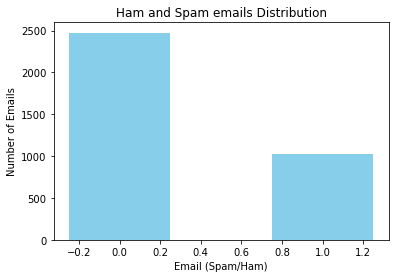

In [222]:
#  Bar plot
plt.bar(np.unique(training_data.label),training_data.label.value_counts(), color ='skyblue',
        width = 0.5)
plt.xlabel("Email (Spam/Ham)")
plt.ylabel("Number of Emails")
plt.title("Ham and Spam emails Distribution")
plt.show()

#training_data.label.value_counts().plot.bar();

Above bargraph shows there are more than twice Spam messages (2474) than the ham/legitimate messages (1021).

Histogram of email lengths in spam and ham messages.

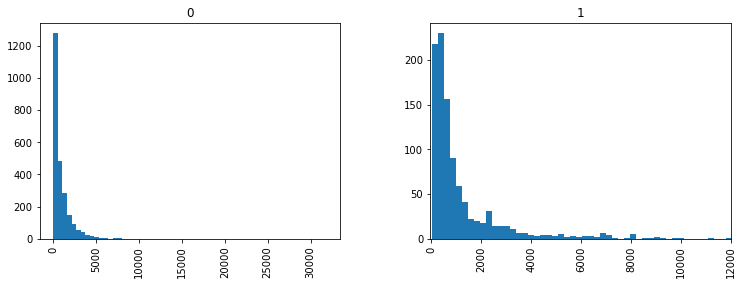

In [224]:
training_data.hist(column='length',by='label',bins=60,figsize=(12,4));
plt.xlim(-40,12000);

In [227]:
training_data['label'].skew()

0.9146171705360151

Above histogram does not give a clear idea as to which type of message (SPAM/HAM) are long, since the bar trends looks same in both the messages.

#### WordClouds - a graphical representation of most frequent words

In [255]:
def show_wordcloud(data_spam_or_ham, title):
    text = ' '.join(data_spam_or_ham['email'].astype(str).tolist())
    stopwords = set(wordcloud.STOPWORDS)
    
    fig_wordcloud = wordcloud.WordCloud(stopwords=stopwords,background_color='lightgrey',
                    colormap='viridis', width=800, height=600).generate(text)
    
    plt.figure(figsize=(10,7), frameon=True)
    plt.imshow(fig_wordcloud)  
    plt.axis('off')
    plt.title(title, fontsize=20 )
    plt.show()                     

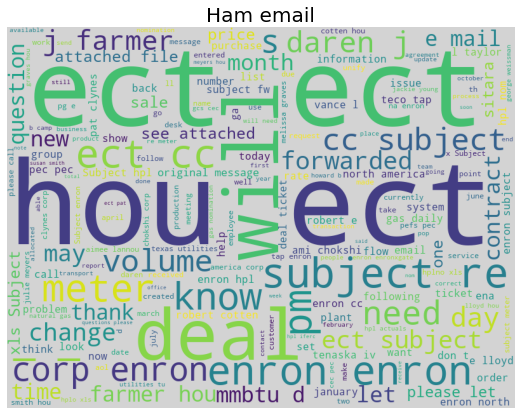

In [256]:
show_wordcloud(ham_df, "Ham email")

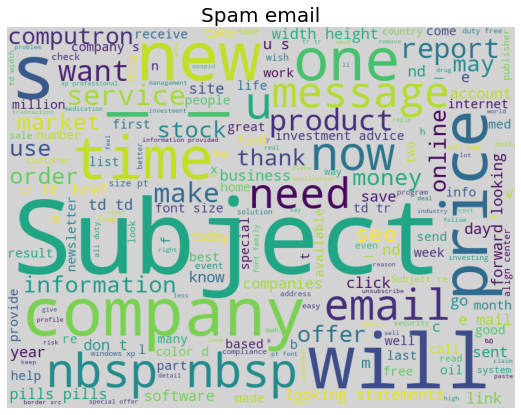

In [257]:
show_wordcloud(spam_df, "Spam email")

Finding top 20 most frequently used words in spam and ham emails.

In [262]:
from collections import Counter

In [258]:
ham_df.loc[:, 'email'] = ham_df['email'].apply(remove_punctuation_and_stopwords)
ham_words = ham_df['email'].tolist()

In [260]:
ham_words_list = []
for word in ham_words:
    for ch in word:
        ham_words_list.append(ch)


In [263]:
ham_counter  = Counter(ham_words_list)
top_20_most_frequent_ham_words  = pd.DataFrame(ham_counter.most_common(20),  columns=['word', 'count'])

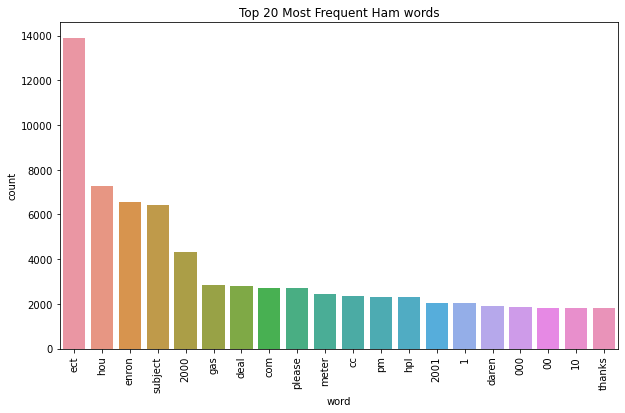

In [264]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='word', y='count', 
            data=top_20_most_frequent_ham_words, ax=ax)
plt.title("Top 20 Most Frequent Ham words")
plt.xticks(rotation='vertical');

In [265]:
spam_df.loc[:, 'email'] = spam_df['email'].apply(remove_punctuation_and_stopwords)
spam_words = spam_df['email'].tolist()

In [266]:
spam_words_list = []
for word in spam_words:
    for ch in word:
        spam_words_list.append(ch)

In [267]:
spam_counter = Counter(spam_words_list)
top_20_most_frequent_spam_word = pd.DataFrame(spam_counter.most_common(20), columns=['word', 'count'])

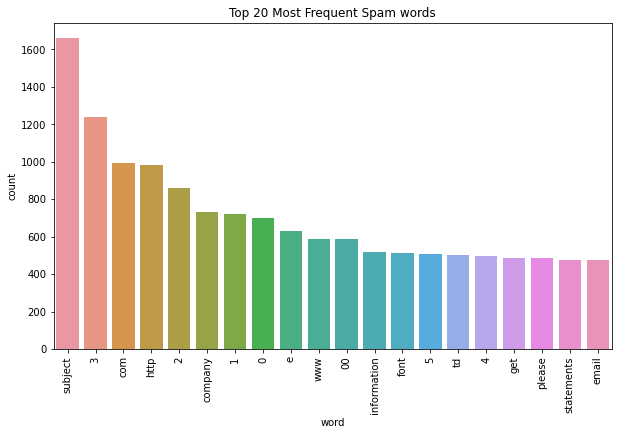

In [268]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='word', y='count', 
            data=top_20_most_frequent_spam_word, ax=ax)
plt.title("Top 20 Most Frequent Spam words")
plt.xticks(rotation='vertical');

Now that we are somewhat aware of our textual dataset we can proceed further to next stage.

# 3. Supervised Classification and Model selection

In this stage, we will fill our training vectorised data into various machine learning models and will evaluate validation accuracy, In this way we can identify how accurate is our model and will also help us to identify many of the emails are correctly classified or misclassified by the model.

I have tried to fit 2 Machine learning models:

1. Multinomial naive bayes
3. Random Forest

We will try to evaluate accuracy for each of the above models and compare them.

#### Train test split to apply in model

In [270]:
train_emails, test_emails, label_train, label_test = \
    train_test_split(data["email"], data["label"], test_size=0.3, random_state=5)

In [271]:
train_emails.head()

1321    Subject: \nhow does the lowest rate in us hist...
872     Subject: re : hungry mhetor cheating on spouse...
1090    Subject: oasis contract imbalance update\n. . ...
366     Subject: weekend noms\n- - - - - - - - - - - -...
108     Subject: eol application id and password\ndarr...
Name: email, dtype: object

### Classification Pipelines

After splitting the data into a train and test set I have used a pipeline to apply the
CountVectorizer and the TfidfTransformer.I have added model classifier to the pipeline and then evaluated accuracy through pipeline.

In [272]:
from sklearn.feature_extraction.text import TfidfVectorizer

##### 3.1 Naive Bayes Classifier implemented trhough pipeline

In [273]:
from sklearn.feature_extraction.text import TfidfVectorizer
pipe_MNB = Pipeline([ ('tfidf_vec' , TfidfVectorizer(analyzer = remove_punctuation_and_stopwords)),
                               ('clf_MNB'   , MultinomialNB()),
                            ])

In [274]:
pipe_MNB.fit(X=train_emails, y=label_train)
pred_MNB = pipe_MNB.predict(test_emails)

0.9019346230820547
0.9019346230820547


In [302]:
print(confusion_matrix(label_test,pred_MNB))
print(classification_report(label_test,pred_MNB))
print(accuracy_score(label_test, pred_MNB))

[[1057    0]
 [ 147  295]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      1057
           1       1.00      0.67      0.80       442

    accuracy                           0.90      1499
   macro avg       0.94      0.83      0.87      1499
weighted avg       0.91      0.90      0.90      1499

0.9019346230820547


#### Naive bayes Multinomial model yieds accuracy of 90%  on test dataset, 

with precision of ham as 0.88 meaning 88% chance model predicts correct ham and Spam as 1 (meaning 100% chance model predicts correct spam) meaning accuracy of identifying spam is more than that of identifying ham email.

Recall: Higher recall is a sign of good classifier, as per MNB model is concerned it classifies ham better than Spam. 

F1-score : It is the harmonic mean of precision and recall. 

For identifying ham its 0.93 
For identifying spam its 0.80 

According to F1- Score Prediction for ham is better than Spam.

#### 3.2 Random Forest (RF) implemented through pipeline

In [295]:
pipe_RF = Pipeline([ ('tfidf_vec' , TfidfVectorizer(analyzer = remove_punctuation_and_stopwords) ),
                   ('clf_RF' , RandomForestClassifier(n_estimators=100) )
                    ])

In [297]:
pipe_RF.fit(train_emails,label_train)
RF_pred = pipe_RF.predict(test_emails)

In [298]:
print(confusion_matrix(label_test,RF_pred))
print(classification_report(label_test,RF_pred))
print(accuracy_score(label_test, RF_pred))

[[1035   22]
 [   6  436]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1057
           1       0.95      0.99      0.97       442

    accuracy                           0.98      1499
   macro avg       0.97      0.98      0.98      1499
weighted avg       0.98      0.98      0.98      1499

0.981320880587058


#### Random Forest model yieds accuracy of 98%  on test dataset.

with precision of ham as 0.99 meaning 99% chance model predicts correct ham and Spam as 0.95 (meaning 95% chance model predicts correct spam) meaning accuracy of identifying ham is more than that of classifying spam email.

Recall: Higher recall is a sign of good classifier, as per RF model  is concerned it classifies spam better than ham emails. 

F1-score : It is the harmonic mean of precision and recall. 

For identifying ham its 0.99
For identifying spam its 0.97 

According to F1- Score Prediction for ham is better than Spam.

#### Saving and Loading the Model 

In the script above, our machine learning model did not take much time to execute. One of the reasons for the quick training time is the fact that we had a relatively smaller training set. We had 2000 documents, of which we used 80% (1600) for training. However, in real-world scenarios, there can be millions of documents. In such cases, it can take hours or even days (if you have slower machines) to train the algorithms. Therefore, it is recommended to save the model once it is trained.

We can save our model as a pickle object in Python. To do so, execute the following script:

In [301]:
import pickle
with open('text_classifier', 'wb') as picklefile:
    pickle.dump(pipe_MNB,picklefile)
    pickle.dump(pipe_RF,picklefile)

Once you execute the above script, you can see the text_classifier file in your working directory. We have saved our trained model and we can use it later for directly making predictions, without training.

# 4. Model Comparison

As we train your classification predictive model, we will need to assess how good it is performing, there are many different ways of evaluating the performance. We are using the most popular among data scientists Python package called scikit-learn. Scikit-learn contains many built-in functions for analyzing the performance of models.

Predictive models rarely predict everything perfectly, so there are many performance metrics that can be used to analyze our models. Although there are number of metrics available,  I will be exploring below list of performnce matrics to evaluate accuracy.

1. confusion_matrix
2. accuracy_score
3. recall_score or Sensitivity_score
4. precision_score

All the matrix evaluation is based on four main values 
1. True Positives: Email is spam/ham and we predict it is actually spam/ham
2. True Negatives: Email is not spam/ham but we predict it is spam/ham and we predicted same
3. False Positives: Email is not spam/ham but we predict it is spam/ham
4. False Negatives: Email is spam/ham but we predict it is not spam/ham

In [303]:
from sklearn.metrics import precision_score, recall_score

Using seaborn heat map to plot confusion matrix.

In [304]:
def plot_confusion_matrix(y_true, y_pred):
    mtx = confusion_matrix(y_true, y_pred)
    sns.heatmap(mtx, annot=True, fmt='d', linewidths=.5,  
                cmap="Blues", square=True, cbar=False) 
    plt.ylabel('true label')
    plt.xlabel('predicted label')

Dictionary of predictions

In [305]:
list_clf = ["MNB", "RF"]

list_pred = [pred_test_MNB_tfidfvec, RF_pred]

dict_pred = dict(zip(list_clf, list_pred))

In [310]:
def plot_all_confusion_matrices(y_true, dict_all_pred, str_title):
    
    list_classifiers = list(dict_all_pred.keys())
    plt.figure(figsize=(15,15))
    plt.suptitle(str_title, fontsize=20, fontweight='bold')
    n=231

    for clf in list_classifiers : 
        plt.subplot(n)
        plot_confusion_matrix(y_true, dict_all_pred[clf])
        plt.title(clf, fontweight='bold')
        n+=1

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)

#### Plotting confusion metrix for each of the three models.

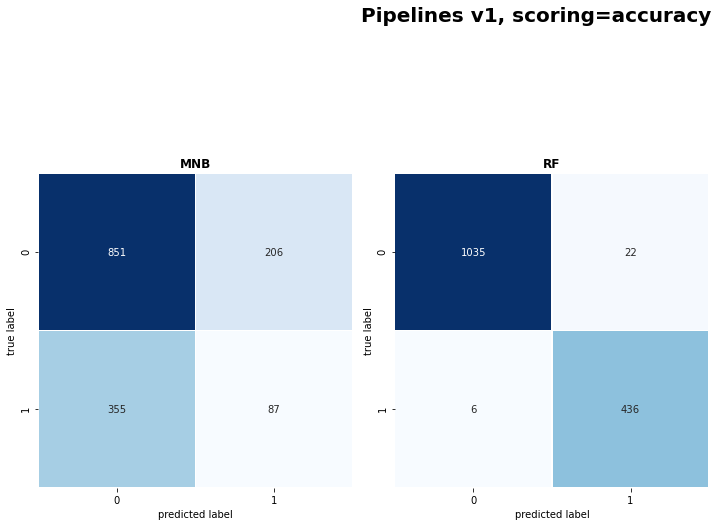

In [311]:
plot_all_confusion_matrices(label_test, dict_pred, "Pipelines v1, scoring=accuracy")

Confusion matrix for MNB :

TP - 851
TN - 87
FP - 206
FN - 365


Confusion matrix for RF :

TP - 1035
TN - 436
FP - 22
FN - 6

#### accuracy_score

The most common metric for classification is accuracy, which is the fraction of samples predicted correctly.

accuracy_score = correct predictions / total predictions = (TP + TN) / (TP + TN + FP + FN)

In [312]:
dict_acc = {}
for clf in list_clf :
    dict_acc[clf] = accuracy_score(label_test, dict_pred[clf])

By definition the precision is calculated for the negative class (label = 0, ham mails).
This is also the default when calling precision score without any further parameters.
But we can also examine the precision for the individual labels (ham,spam = 0,1)

In [313]:
for clf in list_clf :
    print(clf, " ", precision_score(label_test, dict_pred[clf], average=None, labels=[0,1]))

MNB   [0.70563847 0.29692833]
RF   [0.99423631 0.95196507]


#### recall_score 

The recall is is the fraction of positives events we predicted correctly i.e,. TP / (TP + FN).

In [314]:
for clf in list_clf :
    print(clf, " ", recall_score(label_test, dict_pred[clf], average=None, labels=[0,1] ))

MNB   [0.8051088  0.19683258]
RF   [0.97918638 0.98642534]


#### precision_score 

Precision is the fraction of predicted positives events that are actually positive i.e., the ratio TP / (TP + FP) 

In [315]:
for clf in list_clf :
    print(clf, " ", precision_score(label_test, dict_pred[clf], average=None, labels=[0,1]))

MNB   [0.70563847 0.29692833]
RF   [0.99423631 0.95196507]


In predictive analytics, when deciding between two models it is important to pick a single performance metric, while considering accuracy score Random forest out performs Multinomial Naive bayes classifier and has a accuracy score of 0.99423631 (99% accurate) in classifying ham emails and 0.95196507 (95% accurate) in classifying Spam emails.

# References

Below is the list of refereces taken from internet to learn and accomplish assignment.

1. https://stackabuse.com/text-classification-with-python-and-scikit-learn/
2. https://towardsdatascience.com/multi-class-text-classification-model-comparison-and-selection-5eb066197568
3. https://towardsdatascience.com/understanding-data-science-classification-metrics-in-scikit-learn-in-python-3bc336865019
4. https://scikit-learn.org/stable/modules/model_evaluation.html
5. https://www.mygreatlearning.com/blog/bag-of-words/
6. https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction
7. https://www.datacamp.com/community/tutorials/naive-bayes-scikit-learn
8. https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html#sklearn.feature_extraction.text.CountVectorizer
9. https://www.kaggle.com/adamschroeder/countvectorizer-tfidfvectorizer-predict-comments#Graphing-coefficients-of-tokens-in-toxic-comments
10. https://towardsdatascience.com/understanding-data-science-classification-metrics-in-scikit-learn-in-python-3bc336865019